# Hyperparameter Inverse PINN
## Lambda Data Sweep


In [30]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

# Sweep
import itertools


In [31]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")


remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 108.64 KiB | 777.00 KiB/s, done.
From https://github.com/egil10/fys5429
   9412e75..ed40958  main       -> origin/main
Updating 9412e75..ed40958
Fast-forward
 code/notebooks/hyper_inv_1_data.ipynb | 72 +++++++++++++++--------------------
 1 file changed, 31 insertions(+), 41 deletions(-)
Working directory: /content/fys5429/code/notebooks


### Colab setup


In [32]:
data_path = Path("..") / "data" / "generated" / "inv_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "plots" / "eda"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")


Mounted at /content/drive
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda


In [33]:
import sys
sys.path.insert(0, "../scripts")
from invpinn import INVPINN
from train_inv import train_inv_pinn

### Global parameters


In [34]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.backends.cudnn.benchmark = True

# Domain (same as forward)
S_max = 300.0
T_max = 1.0
K = 100.0
r = 0.05
v_min = 0.01
v_max = 1.0
v0 = 0.04

# NN architecture (Phase 2 Upgrade)
HIDDEN_LAYERS = 3
NEURONS_PER_LAYER = 256
ACTIVATION = 'siren'        # UPGRADED TO SIREN

# Learning Rates - Slow down slightly for precision
LEARNING_RATE = 2e-3
LR_HESTON = 1e-3

# Physics lambdas - BRINGING THE LAW BACK
LAMBDA_PDE = 20.0     # INCREASED (Force parameters to obey the PDE)
LAMBDA_IC  = 10.0
LAMBDA_BC  = 5.0
LAMBDA_FELLER = 0.1   # RE-ENABLE LIGHTLY (Help steer away from invalid zones)  

# SWEEP: Keep the data weight very high to maintain the grip
LAMBDA_DATA_VALUES = [500.0, 1000.0, 2000.0]

# Intentionally wrong initial guesses
KAPPA_INIT = 1.0    # True: 2.0
THETA_INIT = 0.1    # True: 0.04
XI_INIT    = 0.5    # True: 0.3
RHO_INIT   = 0.0    # True: -0.7

# Two-Stage Sweep Epochs
EPOCHS_ADAM = 20000 
EPOCHS_LBFGS = 5000


Using device: cuda


In [35]:
if not data_path.exists():
    raise FileNotFoundError(f"Data not found at {data_path}. Run generate_inv.ipynb first.")
else:
    df_all = pd.read_parquet(data_path)
    print(f"Loaded data from {data_path}")

def extract_tensors(df_subset):
    S = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    v = torch.tensor(df_subset['v'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S, v, tau

# Interior (PDE)
df_interior = df_all[df_all['point_type'] == 'interior']
S_in, v_in, tau_in = extract_tensors(df_interior)

# IC 
df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, v_ic, tau_ic = extract_tensors(df_ic)

# BC (S=0 only, as per the fix from forward solver)
df_bc = df_all[df_all['point_type'] == 'boundary_S_lower']
S_bc, v_bc, tau_bc = extract_tensors(df_bc)

# Market data (NEW)
df_data = df_all[df_all['point_type'] == 'market_data']
S_data, v_data, tau_data = extract_tensors(df_data)
V_data = torch.tensor(df_data['V_data'].values, dtype=torch.float32).view(-1, 1).to(device)

print(f"Interior: {len(S_in)}, IC: {len(S_ic)}, BC: {len(S_bc)}, Data: {len(S_data)}")


Loaded data from ../data/generated/inv_collocation.parquet
Interior: 10000, IC: 2000, BC: 250, Data: 200


In [36]:
sweep_results = []
start_time = time.time()
total_runs = len(LAMBDA_DATA_VALUES)

header = f"{'#':>3} | {'λ_data':>8} | {'PDE':>10} {'IC':>10} {'BC':>10} {'Data':>10} {'Feller':>10} | {'κ':>6} {'θ':>6} {'ξ':>6} {'ρ':>6} | {'Time':>5}"
print(header)
print("─" * len(header))

for i, lam_data in enumerate(LAMBDA_DATA_VALUES):
    run_start = time.time()

    result = train_inv_pinn(
        S_in, v_in, tau_in,
        S_ic, v_ic, tau_ic,
        S_bc, v_bc, tau_bc,
        S_data, v_data, tau_data, V_data,
        r, K, device,
        LAMBDA_PDE, LAMBDA_IC, LAMBDA_BC, lam_data, 
        epochs_adam=EPOCHS_ADAM, epochs_lbfgs=EPOCHS_LBFGS,  # UPDATED TO TWO-STAGE
        lr=LEARNING_RATE, lr_heston=LR_HESTON,
        lambda_feller=LAMBDA_FELLER,
        hidden_layers=HIDDEN_LAYERS,
        neurons=NEURONS_PER_LAYER, activation=ACTIVATION,
        kappa_init=KAPPA_INIT, theta_init=THETA_INIT,
        xi_init=XI_INIT, rho_init=RHO_INIT
    )

    result['lambda_data'] = lam_data
    sweep_results.append(result)

    run_sec = time.time() - run_start
    print(f"{i+1:>3} | {lam_data:>8.1f} | "
          f"{result['final_pde']:>10.4f} {result['final_ic']:>10.4f} "
          f"{result['final_bc']:>10.6f} {result['final_data']:>10.4f} "
          f"{result['final_feller']:>10.6f} | "
          f"{result['final_kappa']:>6.3f} {result['final_theta']:>6.4f} "
          f"{result['final_xi']:>6.3f} {result['final_rho']:>6.3f} | "
          f"{run_sec:>5.0f}s")

elapsed = time.time() - start_time
print("─" * len(header))
print(f"Sweep complete: {len(sweep_results)} runs in {int(elapsed//60)}m {int(elapsed%60):02d}s")


  # |   λ_data |        PDE         IC         BC       Data     Feller |      κ      θ      ξ      ρ |  Time
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1 |    500.0 |     0.4960     0.3833   0.002362     0.0116   0.000000 |  1.560 0.0274  0.090  0.930 |   388s
  2 |   1000.0 |     0.7398     0.4730   0.003246     0.0050   0.000000 |  1.541 0.0311  0.115  0.986 |   387s
  3 |   2000.0 |     0.7269     0.6274   0.004022     0.0013   0.000000 |  1.607 0.0242  0.117  0.996 |   388s
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
Sweep complete: 3 runs in 19m 22s


In [37]:
df_sweep = pd.DataFrame([{
    'lambda_data': r['lambda_data'],
    'pde_loss': r['final_pde'],
    'data_loss': r['final_data'],
    'total_loss': r['final_total'],
    'kappa': r['final_kappa'],
    'theta': r['final_theta'],
    'xi': r['final_xi'],
    'rho': r['final_rho'],
} for r in sweep_results])

df_sweep = df_sweep.sort_values('data_loss')
print(df_sweep.to_string(index=False))


 lambda_data  pde_loss  data_loss  total_loss    kappa    theta       xi      rho
      2000.0  0.726944   0.001262   23.356535 1.607269 0.024233 0.117130 0.996447
      1000.0  0.739756   0.004975   24.516087 1.540576 0.031124 0.115014 0.986054
       500.0  0.496033   0.011592   19.561661 1.560112 0.027388 0.089796 0.929901


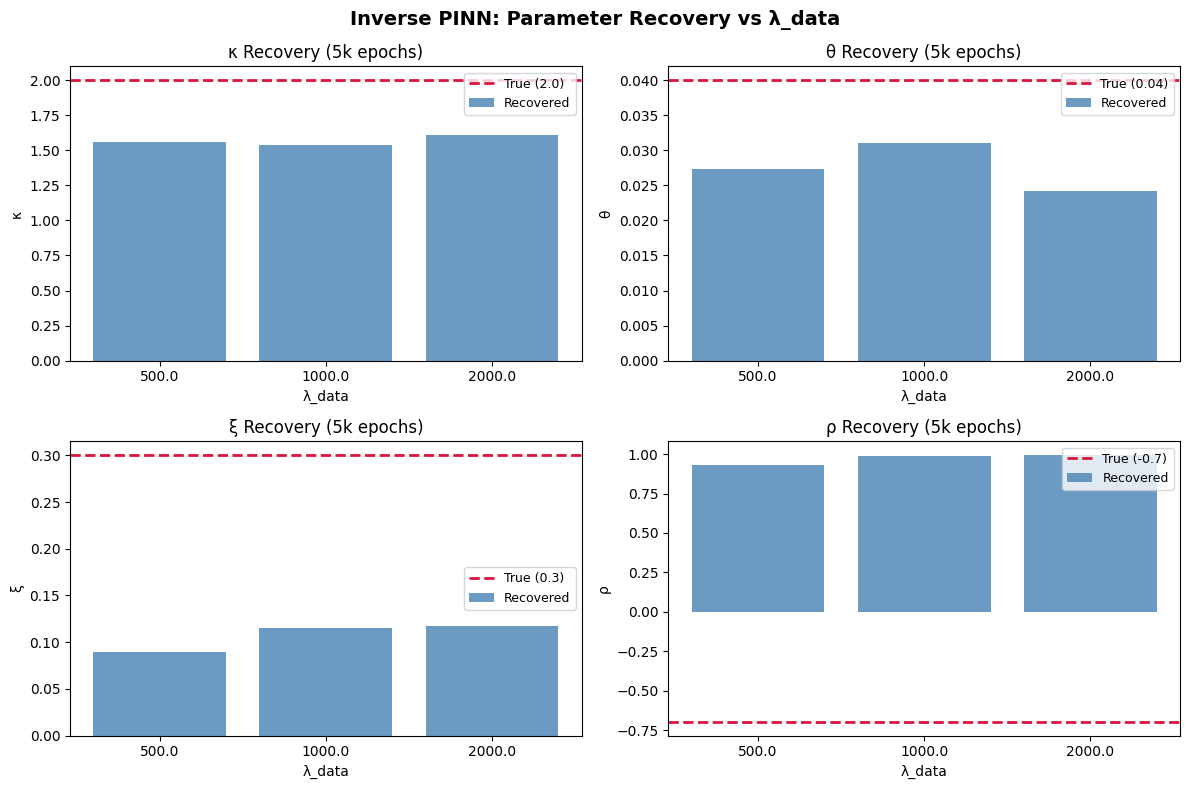

In [38]:
# --- Parameter Recovery Plot ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

true_values = {'kappa': 2.0, 'theta': 0.04, 'xi': 0.3, 'rho': -0.7}
param_names = ['kappa', 'theta', 'xi', 'rho']
param_labels = ['κ', 'θ', 'ξ', 'ρ']

df_plot = df_sweep.sort_values('lambda_data')

for ax, param, label in zip(axes.flat, param_names, param_labels):
    true_val = true_values[param]
    
    ax.bar(df_plot['lambda_data'].astype(str), df_plot[param], 
           color='steelblue', alpha=0.8, label='Recovered')
    ax.axhline(y=true_val, color='crimson', linestyle='--', linewidth=2, label=f'True ({true_val})')
    ax.set_xlabel('λ_data')
    ax.set_ylabel(label)
    ax.set_title(f'{label} Recovery (5k epochs)')
    ax.legend(fontsize=9)

plt.suptitle('Inverse PINN: Parameter Recovery vs λ_data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / "hyper_inv_param_recovery.pdf", bbox_inches="tight")
plt.show()


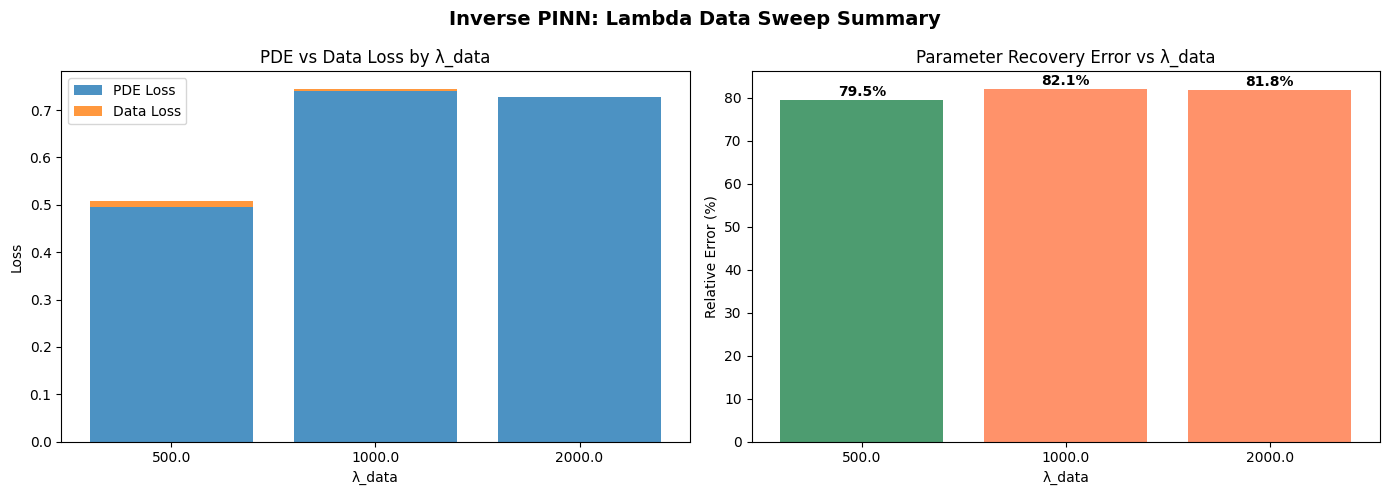

In [39]:
# --- Loss Comparison Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df_plot = df_sweep.sort_values('lambda_data')
x = df_plot['lambda_data'].astype(str)

# Left: Individual losses
ax1.bar(x, df_plot['pde_loss'], label='PDE Loss', alpha=0.8)
ax1.bar(x, df_plot['data_loss'], bottom=df_plot['pde_loss'], label='Data Loss', alpha=0.8)
ax1.set_xlabel('λ_data')
ax1.set_ylabel('Loss')
ax1.set_title('PDE vs Data Loss by λ_data')
ax1.legend()

# Right: Parameter error (L2 distance from truth)
true_vec = np.array([2.0, 0.04, 0.3, -0.7])
param_errors = []
for _, row in df_plot.iterrows():
    recovered = np.array([row['kappa'], row['theta'], row['xi'], row['rho']])
    err = np.linalg.norm(recovered - true_vec) / np.linalg.norm(true_vec)
    param_errors.append(err * 100)

colors = ['seagreen' if e == min(param_errors) else 'coral' for e in param_errors]
ax2.bar(x, param_errors, color=colors, alpha=0.85)
ax2.set_xlabel('λ_data')
ax2.set_ylabel('Relative Error (%)')
ax2.set_title('Parameter Recovery Error vs λ_data')
for i, v in enumerate(param_errors):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Inverse PINN: Lambda Data Sweep Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / "hyper_inv_lambda_data_sweep.pdf", bbox_inches="tight")
plt.show()


In [40]:
if IN_COLAB:
    from google.colab import drive
    drive.flush_and_unmount()
    print("Google Drive flushed and unmounted safely.")


Google Drive flushed and unmounted safely.
